# Name: Peter Mangoro

In [ ]:
# GDP Case Study: California Housing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Set plotting style for later 
sns.set(style="whitegrid", context="notebook")

# Load California Housing dataset as a pandas DataFrame
california = fetch_california_housing(as_frame=True)
X = california.data.copy()
y = california.target.copy()  # MedHouseVal

# Combine into a single DataFrame for convenience
df = X.copy()
df["MedHouseVal"] = y

print("Shape of feature matrix X:", X.shape)
print("Shape of target y:", y.shape)
print("Columns in X:", list(X.columns))


Shape of feature matrix X: (20640, 8)
Shape of target y: (20640,)
Columns in X: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Variable definitions (California Housing features)

Based on the dataset documentation (`california.DESCR`):

- `MedInc`: Median income in the block group, in tens of thousands of dollars (e.g. 8.0 ≈ $80,000).
- `HouseAge`: Median house age in the block group, in years.
- `AveRooms`: Average number of rooms per household (total rooms / households).
- `AveBedrms`: Average number of bedrooms per household (total bedrooms / households).
- `Population`: Total population of the block group.
- `AveOccup`: Average household occupancy, computed as population / households (a proxy for crowding).
- `Latitude`: Latitude (in degrees) of the block group centroid.
- `Longitude`: Longitude (in degrees) of the block group centroid.
- `MedHouseVal`: Median house value in the block group, in $100,000s (e.g. 2.0 ≈ $200,000).

In [3]:
# Inspect the built-in dataset description from scikit-learn

print(california.DESCR[:2000])  # show the first 2000 characters for readability

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:

print("First 5 rows:")
df.head()  


First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# confirm data has loaded correctly with no missing values
print("Missing values per column:")
print(df.isna().sum())


Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
# Create a reproducible train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Validation shapes:", X_valid.shape, y_valid.shape)

Train shapes: (16512, 8) (16512,)
Validation shapes: (4128, 8) (4128,)


## Data Generating Process (DGP) Hypothesis

In this case study, the target variable `MedHouseVal` (median house value in a census tract) is continuous, so I frame the problem as a **regression** task. I assume that house values are generated by an underlying function of observed area-level characteristics plus random noise, which I can write informally as:

`MedHouseVal = f(MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude) + ε.`

Intuitively:
- Higher **median income** (`MedInc`) should increase house values.
- **Rooms and bedrooms per household** (`AveRooms`, `AveBedrms`) reflect housing size/quality.
- **Crowding and density** (`Population`, `AveOccup`) may reduce prices if high, but could also signal desirable urban centers.
- **Location** (`Latitude`, `Longitude`) captures proximity to the coast, urban areas, and amenities, which is known to strongly affect California housing prices.

The noise term `ε` aggregates factors I do not observe or measure precisely, such as:
- Short-term market fluctuations and negotiation outcomes,
- Measurement error in reported incomes or housing characteristics,
- Household-level preferences and shocks.

There are also important **omitted variables** that likely affect prices but are not in this dataset, such as crime rates, school quality, transport access, zoning rules, interest rates, and local amenities. Their omission can bias coefficient interpretations if they are correlated with observed features (e.g., higher income areas also having better schools).

Finally, there may be **sampling bias**: this dataset covers only California and a specific time period, and uses census tracts as units. Relationships I estimate here may not generalize to other states, rural areas, or different market conditions.

Later I will use EDA, feature engineering, and modeling to probe the shape of \(f\) (e.g. linear vs nonlinear effects, interactions, and dominant predictors).

## Exploratory Data Analysis (EDA)

I explore the marginal distributions of the variables, the relationships between `MedHouseVal` and key predictors, and the overall correlation structure. The goal is to build intuition about the data-generating process and to identify patterns (e.g. skewness, nonlinearity, multicollinearity) that will guide feature engineering and model choice in later phases.

In [7]:
# Numeric summaries (excluding geographic coordinates)

num_features = [col for col in df.columns if col not in ["Latitude", "Longitude"]]
summary = df[num_features].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


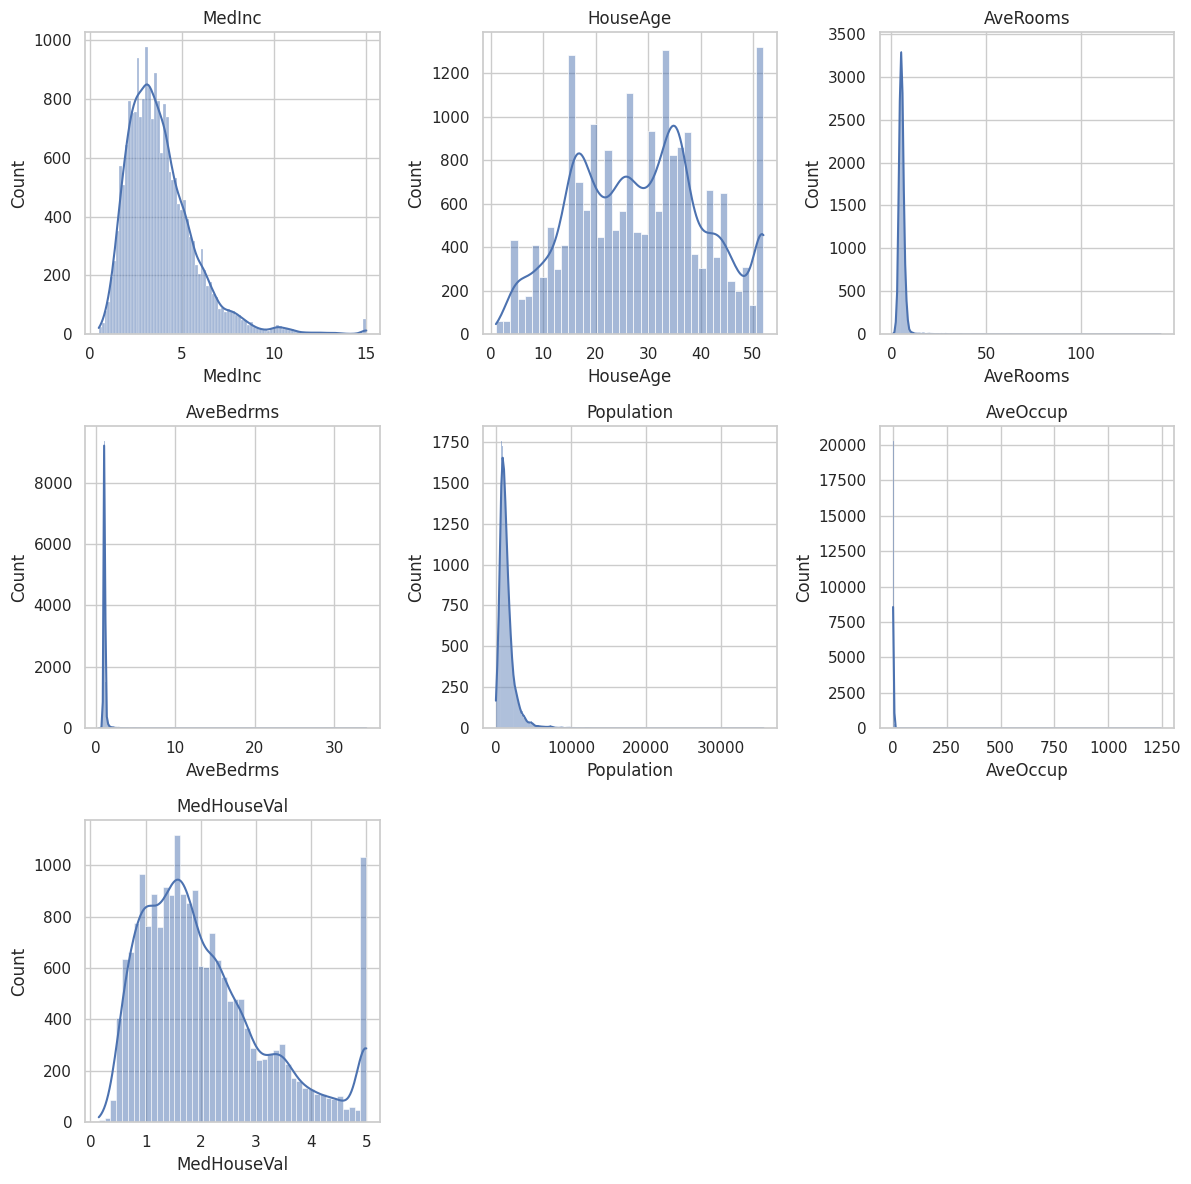

In [8]:
# Marginal distributions (histograms with KDE, excluding coordinates)

num_cols = [col for col in df.columns if col not in ["Latitude", "Longitude"]]

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

# Hide any unused subplots
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Dataset summary and Histograms explanations

**Median income (`MedInc`)** ranges from about 0.5 to 15 (in $10k units), with a mean around 3.87. The long upper tail relative to the quartiles indicates strong right-skewness: most block groups sit in the lower-middle income range, with a small number of very high-income areas. This suggests that a log or other nonlinear transform of income may be helpful in later models.

**House age (`HouseAge`)** spans from 1 to 52 years, with a mean near 28.6. The distribution is not perfectly unimodal and likely reflects different construction eras, so a strictly linear effect of age may be too simplistic.

**Average rooms (`AveRooms`)** has a mean of about 5.43 rooms per household, but ranges from ~0.85 to over 140. The extremely large maximum and very small minimum create extreme right skewness and hint at possible outliers or tracts with very unusual household structures (e.g. very few households or data artifacts). These extreme values should be investigated, and I may consider capping or transforming this feature.

**Population** ranges from 3 to over 35,000, with a mean around 1,425. The upper tail is much heavier than the lower tail, again indicating strong right-skewness driven by a few very dense tracts. Models that are sensitive to scale may benefit from transformations or robust approaches here.

**Median house value (`MedHouseVal`)** ranges from about 0.15 to 5.0 (in $100k units), with a mean near 2.07 and a right-skewed distribution. The upper bound at 5.0 suggests censoring of the highest-value tracts, which compresses very expensive areas into a single top category and can affect coefficient estimates.

The correlation matrix and correlations with `MedHouseVal` identify the predictors most strongly associated with the target and reveal that some predictors, such as `AveRooms` and `AveBedrms`, are highly correlated with each other. This redundancy can cause multicollinearity in linear models and motivates the use of regularization or PCA later to stabilize coefficient estimates and reduce effective dimensionality.

Overall, the strong skewness and presence of outliers in several key predictors motivate:
 -  targeted transformations (e.g. logs or polynomial terms), 
 -  cautious outlier handling, and 
 -  modeling choices that are robust to multicollinearity. 
 

### Conditional relationships: `MedHouseVal` vs key predictors

Next, I look at how median house value varies with a few important predictors: median income, average rooms, occupancy, and geographic location. This helps us see whether simple linear relationships are plausible or whether curvature, saturation, or other nonlinear patterns are present.

In the scatterplots below, I focus on four predictors: `MedInc`, `AveRooms`, `HouseAge`, and `AveOccup`. 

- `MedInc` captures local purchasing power and is a natural primary driver of housing prices.
- `AveRooms` reflects typical house size/quality in a tract.
- `HouseAge` summarizes the age of the housing stock, which may affect both physical condition and neighborhood character.
- `AveOccup` measures **crowding** (average people per household), which is more interpretable than raw `Population` because it normalizes by the number of households. High occupancy can indicate overcrowding or multi-family sharing, which may put downward pressure on prices, while moderate occupancy is typical.

These variables together give a compact view of economic status, housing quality, age, and crowding, which are central to the hypothesized data-generating process for `MedHouseVal`.

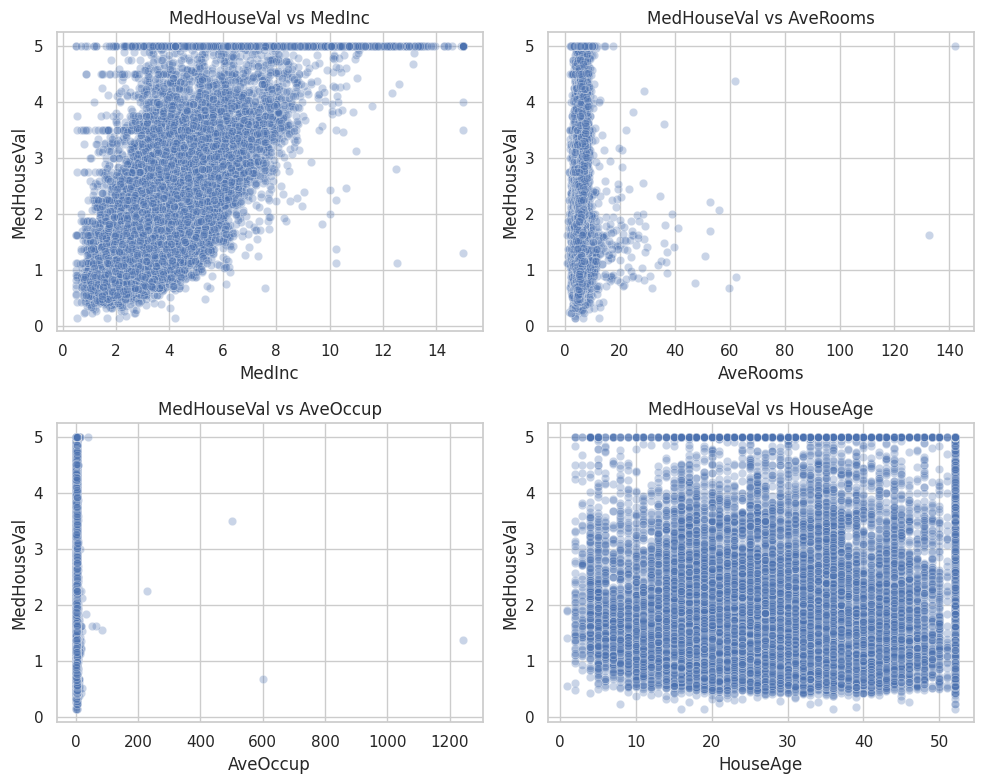

In [ ]:
# Scatterplots of MedHouseVal vs selected predictors 

key_predictors = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_predictors):
    sns.scatterplot(data=df, x=col, y="MedHouseVal", alpha=0.3, ax=ax)
    ax.set_title(f"MedHouseVal vs {col}")

plt.tight_layout()
plt.show()

### Scatterplots in typical ranges

The previous scatterplots include a few extreme values for `AveRooms` and `AveOccup` that stretch the x-axis and make it hard to see patterns for typical tracts. For visualization only, I zoom in on a central range (2–10 rooms, 0.5–8 occupants) to better understand the relationships in the bulk of the data, while still keeping the full dataset unchanged for later modeling.

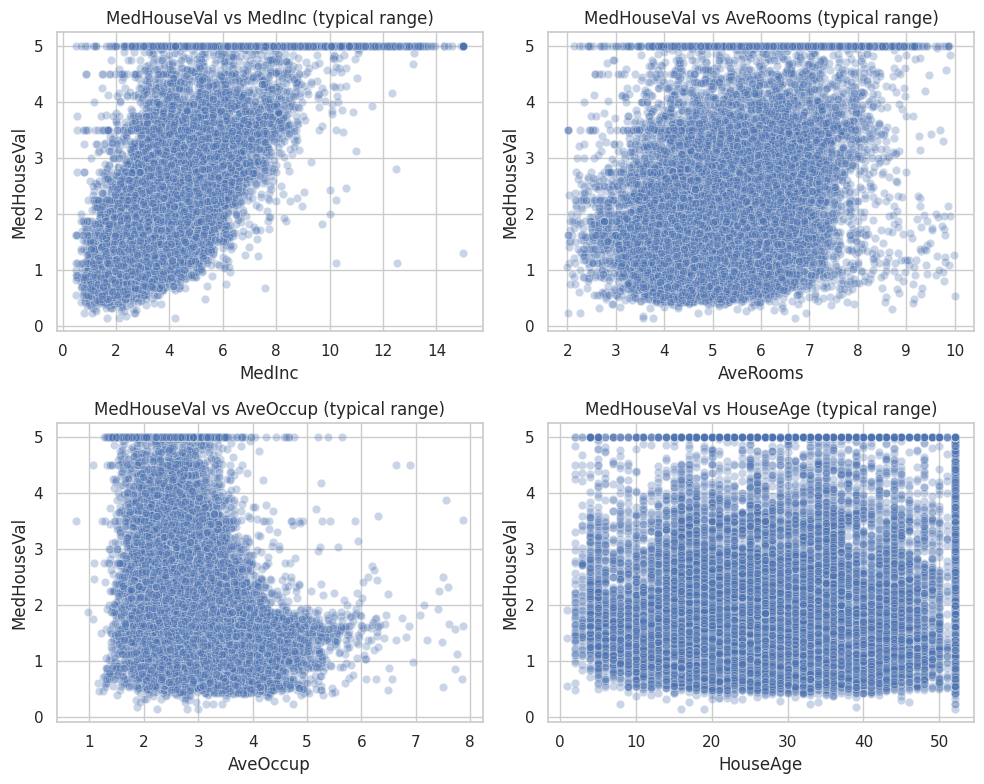

In [ ]:
# Scatterplots within typical ranges for AveRooms and AveOccup

zoom_mask = (
    (df["AveRooms"] >= 2) & (df["AveRooms"] <= 10) &
    (df["AveOccup"] >= 0.5) & (df["AveOccup"] <= 8)
)

df_zoom = df[zoom_mask].copy()

zoom_predictors = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, zoom_predictors):
    sns.scatterplot(data=df_zoom, x=col, y="MedHouseVal", alpha=0.3, ax=ax)
    ax.set_title(f"MedHouseVal vs {col} (typical range)")

plt.tight_layout()
plt.show()

### Interpretation of scatterplots (initial and zoomed)

**MedHouseVal vs `MedInc`**

- There is a **strong positive** relationship: higher median tract income is associated with higher median house values, consistent with affordability and demand.
- The **horizontal band at `MedHouseVal = 5.0`** shows **censoring**: the target is capped in this dataset, so many high-income tracts are recorded at the same top value rather than spreading above 5.
- A few points with **very high `MedInc` but low `MedHouseVal`** are worth treating cautiously: they may reflect **tract composition**, **location** (income and desirability not aligned), or **noise** in aggregated ratios—not necessarily “rich areas with cheap houses” in a simple sense.

**MedHouseVal vs `AveRooms`**

- **Initial plot:** A handful of extreme `AveRooms` values stretch the x-axis and hide the bulk of the data. Remember that `AveRooms` is **average rooms per household** (a **ratio**); very large values can arise when **household counts are tiny**, not only from physically enormous homes.
- **Zoomed (typical range):** Within roughly **3–8 rooms**, the cloud is wide: at most a **weak-to-moderate** positive association. Room count alone does not pin down value as tightly as income; **location and other covariates** likely dominate.

**MedHouseVal vs `AveOccup`**

- **Initial plot:** Almost all points sit in a narrow band near the origin; a few **extreme occupancy** values set the axis scale. `AveOccup` is **population per household** (also a **ratio**), so huge values can reflect **unusual denominators** or odd tracts, not only “crowding” in an everyday sense.
- **Zoomed:** In normal ranges, **higher occupancy tends to associate with lower house values**—consistent with **crowding** or related tract composition. The pattern suggests a **nonlinear** or **threshold** effect rather than a single straight-line slope.

**MedHouseVal vs `HouseAge`**

- There is **no clear overall linear trend**: at the tract level, age mixes **desirable mature neighborhoods** with **older stock and depreciation**, so effects can **cancel** in the margin.
- **Vertical striping** at integer ages and a **heavy line at age 52** (and the **5.0 cap** on `MedHouseVal`) reflect **how the variables are recorded and capped**, not “different households” in the sense of individual homes—this is block-group level data.

**Takeaway for later modeling:** censoring on `MedHouseVal`, ratio-based features (`AveRooms`, `AveOccup`), and weak marginal effects for some predictors motivate **transformations**, **care with outliers**, and possibly **interactions** location.

### Geo EDA (Latitude/Longitude)

Location is a key driver of California housing prices, so I inspect how `MedHouseVal` varies with latitude and longitude and how the two coordinates jointly relate to price.

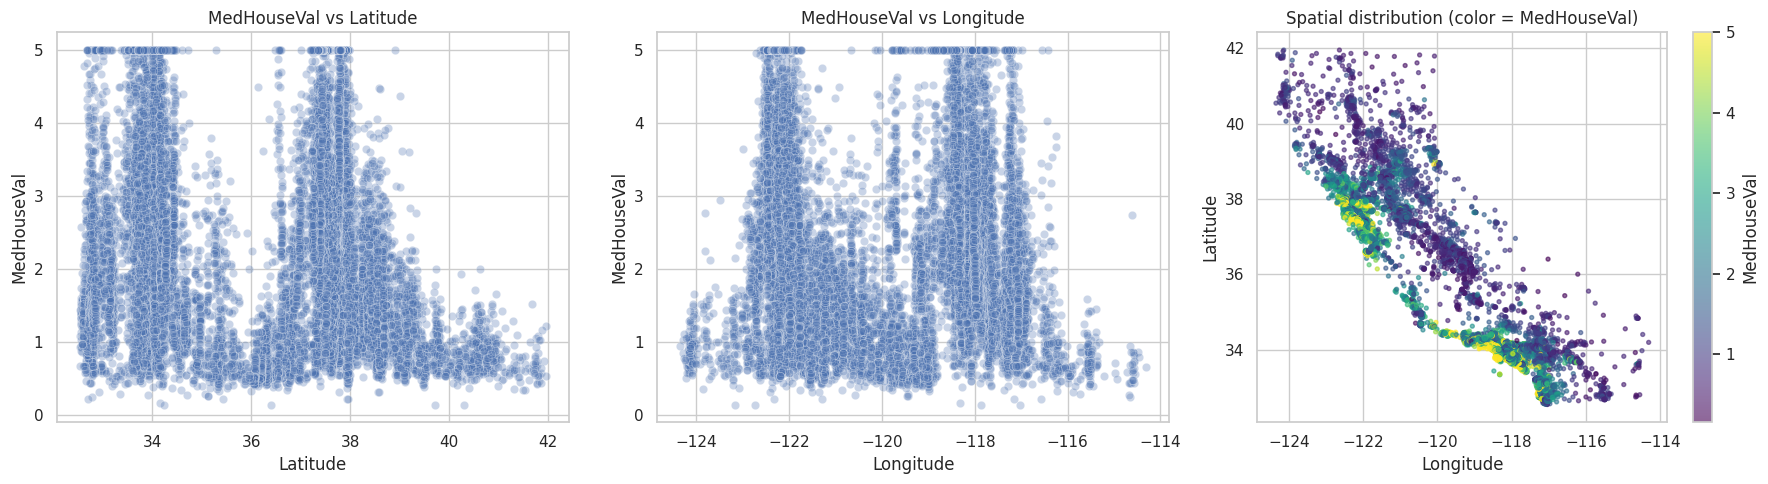

In [11]:
# Geo EDA plots: MedHouseVal vs Latitude/Longitude + spatial scatter colored by price

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.scatterplot(data=df, x="Latitude", y="MedHouseVal", alpha=0.3, ax=axes[0])
axes[0].set_title("MedHouseVal vs Latitude")

sns.scatterplot(data=df, x="Longitude", y="MedHouseVal", alpha=0.3, ax=axes[1])
axes[1].set_title("MedHouseVal vs Longitude")

sc = axes[2].scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="viridis",
    s=8,
    alpha=0.6,
)
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title("Spatial distribution (color = MedHouseVal)")

cbar = fig.colorbar(sc, ax=axes[2])
cbar.set_label("MedHouseVal")

plt.tight_layout()
plt.show()

### Geo EDA interpretation

MedHouseVal shows clear, structured dependence on both Latitude and Longitude. Instead of a single smooth trend, the latitude plot exhibits banding/striping, a sign that geographic location creates distinct spatial regimes and the relationship is non-monotone. The longitude plot also reveals regional variation, with higher values clustered in certain longitudes and lower values more common elsewhere.

The spatial distribution (Longitude vs Latitude, colored by MedHouseVal) makes the overall story clearest: prices form geographic clusters and gradients across California, with higher values concentrated in particular coastal/region-like areas. It implies that geo will be correlated with other predictors (e.g., income and housing characteristics), leading to correlated predictors and instability in plain OLS—motivating regularization and/or PCA later to stabilize estimation. Finally, the visible pile-up near the top price range reflects the dataset’s value cap, so apparent “flat” high areas are partly censoring rather than truly constant prices.

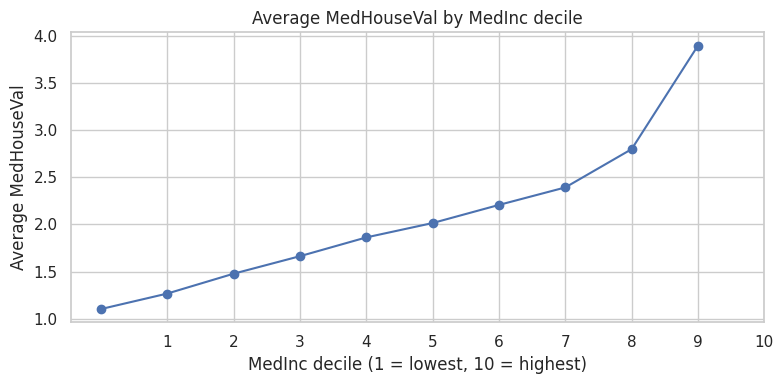

In [ ]:
# Binned relationship between MedInc and MedHouseVal
medinc_bins = pd.qcut(df["MedInc"], q=10, labels=False) 
binned = df.groupby(medinc_bins)["MedHouseVal"].mean().reset_index()
binned.columns = ["decile", "avg_MedHouseVal"]

plt.figure(figsize=(8, 4))
plt.plot(binned["decile"], binned["avg_MedHouseVal"], marker="o")
plt.xlabel("MedInc decile (1 = lowest, 10 = highest)")
plt.ylabel("Average MedHouseVal")
plt.xticks(range(1, 11))
plt.title("Average MedHouseVal by MedInc decile")
plt.tight_layout()
plt.show()


MedHouseVal is grouped by income deciles using MedInc (decile 1 = lowest income, decile 10 = highest). For each decile, the plot shows the average house value, and it rises steadily as income increases, indicating a strong positive relationship between local purchasing power and housing prices. The increase becomes more pronounced in the top deciles, suggesting a nonlinear (steeper at higher income) effect, consistent with the scatterplot pattern and motivating income transformations or nonlinear terms in later modeling.

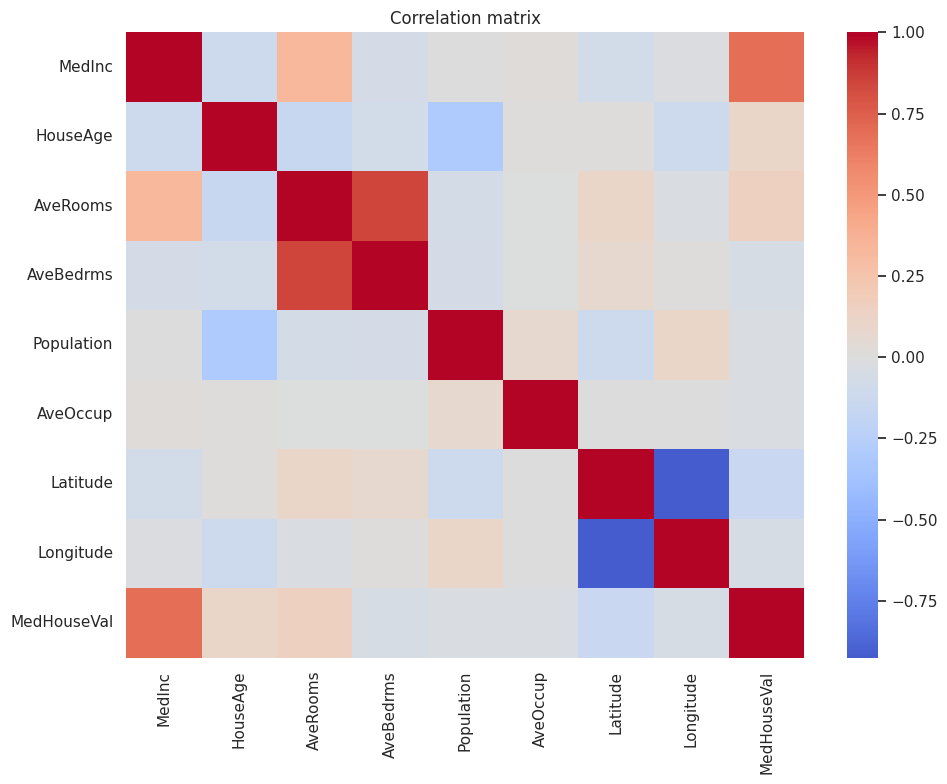

Correlations with MedHouseVal:
 MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [13]:
# Correlation matrix and heatmap 

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

target_corr = corr["MedHouseVal"].sort_values(ascending=False)
print("Correlations with MedHouseVal:\n", target_corr)

Interpretation of correlation matrix (vs MedHouseVal)

The strongest linear association with MedHouseVal is MedInc (correlation ≈ +0.688), indicating that higher income areas tend to have higher median house values. All other predictors show weak marginal linear correlations: AveRooms is only modestly positive (+0.152), while HouseAge is small (+0.106). The crowding/density proxies (AveOccup ≈ -0.024, Population ≈ -0.025) and AveBedrms (≈ -0.047) are essentially near zero with respect to the target, suggesting that any effect they have is likely nonlinear, interaction-based, or diluted by outliers and the dataset’s target cap at 5.0.

For geography, Latitude has a moderate negative correlation (-0.144) and Longitude is slightly negative (-0.046). This indicates some linear regional gradient in prices, but the relatively small magnitude supports that geographic effects are probably structured/nonlinear (spatial clusters) rather than well captured by a single straight-line correlation.

Implication for modeling: since only MedInc shows a strong linear relationship while most others are weak, later phases should rely on feature engineering (logs, interactions, polynomial terms) and regularization/PCA to capture nonlinear structure and manage potential multicollinearity among predictors.

## Feature Engineering (engineered linear predictors)

Earlier, `MedInc` shows the strongest marginal association with `MedHouseVal`, while other predictors have weaker linear correlations and show evidence of skewness, outliers (especially in ratio features like `AveRooms` and `AveOccup`), and nonlinearity/censoring (the target is capped at the top range). Location (`Latitude`/`Longitude`) also shows structured spatial variation.

In this section, I construct a small set of engineered, interpretable features including nonlinear/log transforms, robust/capped versions of ratio variables, and geo interactions. I then compare a baseline linear model using the original predictors to a linear model using engineered features to see whether feature construction improves predictive performance on the validation set while keeping the model interpretable (ceteris-paribus coefficient meaning).

### Leakage-safe feature construction

I construct baseline and engineered predictors using only the **training split** to choose any data-dependent thresholds e.g., capping percentiles and geo reference values. This avoids data leakage and ensures that validation metrics reflect generalization.

I will build:
- `X_base_*`: the original predictors.
- `X_eng_*`: original predictors plus engineered features (log transform, robust/capped ratio features, and geo interactions).

In [14]:
# Build leakage-safe baseline vs engineered features

import numpy as np
import pandas as pd

# Baseline features (original predictors)
X_base_train = X_train.copy()
X_base_valid = X_valid.copy()

# Choose robust caps using training data only (leakage-safe)
ROOMS_CAP_Q = 0.99
OCCUP_CAP_Q = 0.99

rooms_cap = float(np.quantile(X_train["AveRooms"], ROOMS_CAP_Q))
occup_cap = float(np.quantile(X_train["AveOccup"], OCCUP_CAP_Q))

# Geo reference point using training data only
lat0 = float(X_train["Latitude"].mean())
lon0 = float(X_train["Longitude"].mean())

print(f"rooms_cap (q={ROOMS_CAP_Q}): {rooms_cap:.4f}")
print(f"occup_cap (q={OCCUP_CAP_Q}): {occup_cap:.4f}")
print(f"Geo reference lat0/lon0: {lat0:.4f}, {lon0:.4f}")


def add_engineered_features(X: pd.DataFrame, *, rooms_cap: float, occup_cap: float, lat0: float, lon0: float) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-6

    # Nonlinear transform motivated by scatter/histogram skewness
    X["logMedInc"] = np.log1p(X["MedInc"])

    # Robust/capped ratio helpers to reduce influence of extreme values
    X["AveRooms_capped"] = np.minimum(X["AveRooms"], rooms_cap)
    X["AveOccup_capped"] = np.minimum(X["AveOccup"], occup_cap)

    # Interaction-like ratio feature (space per person)
    X["RoomsPerOccup"] = X["AveRooms_capped"] / (X["AveOccup_capped"] + eps)

    # Income-dependent crowding/space interaction
    X["logMedInc_x_RoomsPerOccup"] = X["logMedInc"] * X["RoomsPerOccup"]

    # Geo interactions (linear-in-parameters for linear models)
    X["LatLon"] = X["Latitude"] * X["Longitude"]
    X["GeoDist"] = (X["Latitude"] - lat0) ** 2 + (X["Longitude"] - lon0) ** 2

    return X


# Engineered features for training and validation
X_eng_train = add_engineered_features(
    X_train,
    rooms_cap=rooms_cap,
    occup_cap=occup_cap,
    lat0=lat0,
    lon0=lon0,
)

X_eng_valid = add_engineered_features(
    X_valid,
    rooms_cap=rooms_cap,
    occup_cap=occup_cap,
    lat0=lat0,
    lon0=lon0,
)

print("X_base_train shape:", X_base_train.shape)
print("X_eng_train shape:", X_eng_train.shape)
print("Engineered columns added:", [c for c in X_eng_train.columns if c not in X_base_train.columns])

rooms_cap (q=0.99): 10.3184
occup_cap (q=0.99): 5.4102
Geo reference lat0/lon0: 35.6431, -119.5823
X_base_train shape: (16512, 8)
X_eng_train shape: (16512, 15)
Engineered columns added: ['logMedInc', 'AveRooms_capped', 'AveOccup_capped', 'RoomsPerOccup', 'logMedInc_x_RoomsPerOccup', 'LatLon', 'GeoDist']


### What was constructed (leakage-safe)

The engineered features were built using **training-only** thresholds and reference values:

- `rooms_cap (q=0.99)`: **10.3184** — values of `AveRooms` above this are capped to reduce the impact of extreme outliers.
- `occup_cap (q=0.99)`: **5.4102** — values of `AveOccup` above this are capped for the same reason.
- Geo reference point used in `GeoDist`: `lat0/lon0` = **35.6431**, **-119.5823** (means computed from `X_train`).

Sanity checks on the feature matrices:

- `X_base_train` shape: **(16512, 8)** (original predictors)
- `X_eng_train` shape: **(16512, 15)** (original predictors + engineered features)

Engineered columns added:

- `logMedInc`, `AveRooms_capped`, `AveOccup_capped`, `RoomsPerOccup`, `logMedInc_x_RoomsPerOccup`, `LatLon`, `GeoDist`

I will compare a baseline linear model using `X_base` against an engineered-feature linear model using `X_eng` on the validation set.

### Compare baseline vs engineered linear models (validation)

Here I fit two **leakage-safe** linear models:
- a baseline linear model on the original predictors (`X_base_train`),
- an engineered-feature linear model (`X_eng_train`, using the transforms/features built from training-only thresholds).

I evaluate both on the holdout validation set (`X_base_valid` / `X_eng_valid`, `y_valid`) using RMSE, MAE, and R².

In [15]:
# Fit baseline and engineered linear models on the validation set

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline model: original predictors
baseline_model = LinearRegression()
baseline_model.fit(X_base_train, y_train)

pred_base = baseline_model.predict(X_base_valid)

# Engineered model: original + engineered predictors
engineered_model = LinearRegression()
engineered_model.fit(X_eng_train, y_train)

pred_eng = engineered_model.predict(X_eng_valid)

# Evaluation metrics on validation
mse_base = mean_squared_error(y_valid, pred_base)
rmse_base = np.sqrt(mse_base)
mae_base = mean_absolute_error(y_valid, pred_base)
r2_base = r2_score(y_valid, pred_base)

mse_eng = mean_squared_error(y_valid, pred_eng)
rmse_eng = np.sqrt(mse_eng)
mae_eng = mean_absolute_error(y_valid, pred_eng)
r2_eng = r2_score(y_valid, pred_eng)

results = pd.DataFrame(
    [
        ["Baseline (X_base)", rmse_base, mae_base, r2_base],
        ["Engineered (X_eng)", rmse_eng, mae_eng, r2_eng],
    ],
    columns=["Model", "Val_RMSE", "Val_MAE", "Val_R2"],
).set_index("Model")

print(results)

print("\nValidation R2 improvement:", r2_eng - r2_base)
print("Validation RMSE ratio (eng/base):", rmse_eng / rmse_base)

                    Val_RMSE   Val_MAE    Val_R2
Model                                           
Baseline (X_base)   0.745581  0.533200  0.575788
Engineered (X_eng)  0.665263  0.470192  0.662262

Validation R2 improvement: 0.086474008913759
Validation RMSE ratio (eng/base): 0.8922745822530547


### Commentary on validation results

On the validation set, the engineered linear model improves over the baseline linear model:

- `Val_RMSE`: **0.7456 → 0.6653** (lower error)
- `Val_MAE`: **0.5332 → 0.4702** (lower typical absolute error)
- `Val_R2`: **0.5758 → 0.6623** (higher explained variation)

This indicates that the feature engineering (log transform of income, capped ratio-based crowding/space measures, and geo interaction/distance terms) captures structure in the data-generating process that a simple linear model on raw features misses. Because evaluation is on the holdout validation split and the engineered thresholds were chosen using training data only for leakage-safe, these gains are evidence of better *generalization*, not just better fit to noise.

From a bias–variance perspective, adding appropriately structured nonlinear/interaction features can reduce bias (better approximation of the true relationship) and, in this case, also yields lower validation error, suggesting variance did not increase enough to offset the bias reduction. Interpretability is preserved: this is still a linear model, so coefficients correspond to ceteris-paribus associations on the transformed/capped feature scale.

Next, I can 
 
 (i) inspect coefficient magnitudes/signs for interpretability and 
 
 (ii) proceed to bias–variance comparisons with polynomial/interaction and regularized regressions, where multicollinearity from geo and correlated predictors is expected.

In [16]:
# Inspect coefficient values for interpretability
coef_eng = pd.Series(engineered_model.coef_, index=X_eng_train.columns)
coef_base = pd.Series(baseline_model.coef_, index=X_base_train.columns)

print("Top engineered coefficients by absolute magnitude:")
print(coef_eng.reindex(coef_eng.abs().sort_values(ascending=False).index).head(15))

print("\nTop baseline coefficients by absolute magnitude:")
print(coef_base.reindex(coef_base.abs().sort_values(ascending=False).index).head(10))


Top engineered coefficients by absolute magnitude:
Latitude                     22.994190
Longitude                    -7.514271
logMedInc_x_RoomsPerOccup     0.477345
logMedInc                    -0.311321
AveBedrms                     0.303218
MedInc                        0.272264
RoomsPerOccup                -0.223069
LatLon                        0.196637
AveRooms_capped              -0.174076
AveOccup_capped              -0.119680
GeoDist                       0.095369
AveRooms                     -0.044114
HouseAge                      0.009965
AveOccup                     -0.000818
Population                    0.000043
dtype: float64

Top baseline coefficients by absolute magnitude:
AveBedrms     0.783145
MedInc        0.448675
Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
HouseAge      0.009724
AveOccup     -0.003526
Population   -0.000002
dtype: float64


### Interpreting key engineered terms

From the coefficient inspection of engineered-feature linear model:

- `logMedInc` and its interaction `logMedInc_x_RoomsPerOccup` jointly describe how the income effect depends on “space/crowding” (since `RoomsPerOccup` comes from capped `AveRooms` and `AveOccup`). Because it’s an interaction model, the marginal effect of income is not constant:
  - Approximate marginal effect of `logMedInc`: 
  
  `coef(logMedInc) + coef(logMedInc_x_RoomsPerOccup) * RoomsPerOccup`.

  - The coefficient on `logMedInc` is slightly negative (about -0.311), while the coefficient on `logMedInc_x_RoomsPerOccup` is positive (about +0.477). For typical `RoomsPerOccup` values (median about 1.94), the implied net marginal effect is positive in nearly all tracts, so the income association is still upward overall, and stronger when space-per-person is higher.

- The capped ratio features (`AveRooms_capped`, `AveOccup_capped`, and `RoomsPerOccup`) are designed to reduce the influence of extreme outliers. For values above the training-set caps, these engineered inputs become constant, so the model can’t overreact to rare ratio artifacts.

- I use the geo terms (`Latitude`, `Longitude`, `LatLon`, `GeoDist`) to capture location structure.  `Latitude` has the largest positive coefficient and `Longitude` the largest negative coefficient, which I interpret as a strong conditional geographic gradient. Because several geo predictors overlap and correlate with income and other tract traits, I treat individual geo coefficients as directional rather than precise marginal “effects,” and I lean on validation metrics when I judge overall usefulness.

Overall, I find this engineered linear model improves validation performance while keeping coefficients interpretable on the transformed/capped scale. For me, the main interpretability tension is multicollinearity from correlated predictors and overlapping engineered terms .

## Modeling and Bias–Variance Analysis

In this section, I define shared utilities and fixed evaluation settings so all models are compared consistently. I will use the same metrics (RMSE, MAE, R²), the same CV strategy (K-fold with a fixed random state), and one common result collector table for every model variant.

In [ ]:
# Shared settings, metrics, and evaluation helpers

import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Consistent cross-validation setup
CV_FOLDS = 5
CV_RANDOM_STATE = 42
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=CV_RANDOM_STATE)

ALPHA_GRID = np.logspace(-4, 2, 30)


def regression_metrics(y_true, y_pred):
    """Return RMSE, MAE, R2 in a sklearn-version-safe way."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


def evaluate_model(model, X_train_data, y_train_data, X_valid_data, y_valid_data, model_name):
    """
    Fit model, compute train/validation metrics, and 5-fold CV summaries.
    Returns a dict suitable for appending to a results table.
    """
    # Fit on train split
    model.fit(X_train_data, y_train_data)

    # Train metrics
    pred_train = model.predict(X_train_data)
    train_rmse, train_mae, train_r2 = regression_metrics(y_train_data, pred_train)

    # Validation metrics
    pred_valid = model.predict(X_valid_data)
    val_rmse, val_mae, val_r2 = regression_metrics(y_valid_data, pred_valid)

    # Cross-validation metrics (on training split only)
    cv_scores = cross_validate(
        model,
        X_train_data,
        y_train_data,
        cv=cv,
        scoring=("neg_mean_squared_error", "neg_mean_absolute_error", "r2"),
        n_jobs=None,
    )

    cv_rmse = np.sqrt(-cv_scores["test_neg_mean_squared_error"])
    cv_mae = -cv_scores["test_neg_mean_absolute_error"]
    cv_r2 = cv_scores["test_r2"]

    return {
        "model": model_name,
        "train_rmse": train_rmse,
        "train_mae": train_mae,
        "train_r2": train_r2,
        "cv_rmse_mean": float(np.mean(cv_rmse)),
        "cv_rmse_std": float(np.std(cv_rmse)),
        "cv_mae_mean": float(np.mean(cv_mae)),
        "cv_r2_mean": float(np.mean(cv_r2)),
        "cv_r2_std": float(np.std(cv_r2)),
        "val_rmse": val_rmse,
        "val_mae": val_mae,
        "val_r2": val_r2,
    }


all_model_results = []

print(f"Setup ready: {CV_FOLDS}-fold CV, random_state={CV_RANDOM_STATE}")
print(f"Alpha grid size: {len(ALPHA_GRID)}")

Setup ready: 5-fold CV, random_state=42
Alpha grid size: 30


### Raw-feature baseline track

I first compare model complexity using the **raw predictors** (`X_base_*`) only:

1. OLS baseline
2. Degree-2 polynomial/interaction OLS
3. RidgeCV (scaled)
4. LassoCV (scaled)

For each model, I record train, cross-validated (training split), and holdout validation metrics.

- **OLS, RidgeCV, and LassoCV are nearly identical** (validation RMSE around 0.745 and validation R2 around 0.576), which suggests that on raw features, regularization adds little and these models behave similarly.
- **Raw Poly2 OLS fits training data much better** (train RMSE 0.649, train R2 0.685) and also has stronger holdout validation performance (val RMSE 0.681, val R2 0.646).
- However, **Raw Poly2 OLS shows very unstable CV behavior** (cv RMSE mean 1.390 with std 1.380; cv R2 mean -1.885 with std 5.028), indicating high fold-to-fold variance and sensitivity to distribution shifts/outliers.
- This is a **bias-variance tradeoff pattern**: low-complexity raw linear models are stable but likely higher-bias, while polynomial expansion captures more signal but increases variance without robust feature handling.


In [ ]:
# Raw-feature models: OLS, Polynomial OLS, RidgeCV, LassoCV

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 1) OLS baseline (raw features)
raw_ols = LinearRegression()
res_raw_ols = evaluate_model(
    raw_ols,
    X_base_train,
    y_train,
    X_base_valid,
    y_valid,
    model_name="Raw OLS",
)
all_model_results.append(res_raw_ols)

# 2) Degree-2 polynomial + interactions with OLS
raw_poly2_ols = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
res_raw_poly2_ols = evaluate_model(
    raw_poly2_ols,
    X_base_train,
    y_train,
    X_base_valid,
    y_valid,
    model_name="Raw Poly2 OLS",
)
all_model_results.append(res_raw_poly2_ols)

# 3) RidgeCV (scaled)
raw_ridge = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=ALPHA_GRID, cv=cv)),
    ]
)
res_raw_ridge = evaluate_model(
    raw_ridge,
    X_base_train,
    y_train,
    X_base_valid,
    y_valid,
    model_name="Raw RidgeCV",
)
all_model_results.append(res_raw_ridge)

# 4) LassoCV (scaled)
raw_lasso = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LassoCV(alphas=ALPHA_GRID, cv=cv, random_state=CV_RANDOM_STATE, max_iter=20000),
        ),
    ]
)

import warnings
from sklearn.exceptions import ConvergenceWarning

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    res_raw_lasso = evaluate_model(
        raw_lasso,
        X_base_train,
        y_train,
        X_base_valid,
        y_valid,
        model_name="Raw LassoCV",
    )
all_model_results.append(res_raw_lasso)

raw_model_names = {"Raw OLS", "Raw Poly2 OLS", "Raw RidgeCV", "Raw LassoCV"}
raw_results_df = pd.DataFrame([r for r in all_model_results if r["model"] in raw_model_names])

raw_results_df = raw_results_df[[
    "model",
    "train_rmse", "cv_rmse_mean", "cv_rmse_std", "val_rmse",
    "train_r2", "cv_r2_mean", "cv_r2_std", "val_r2",
]]

raw_results_df = raw_results_df.sort_values("val_rmse").reset_index(drop=True)
print(raw_results_df)

           model  train_rmse  cv_rmse_mean  cv_rmse_std  val_rmse  train_r2  \
0  Raw Poly2 OLS    0.648634      1.390345     1.379680  0.681397  0.685268   
1    Raw LassoCV    0.719693      0.722042     0.014599  0.744939  0.612532   
2    Raw RidgeCV    0.719677      0.720508     0.013898  0.745494  0.612550   
3        Raw OLS    0.719676      0.720510     0.013895  0.745581  0.612551   

   cv_r2_mean  cv_r2_std    val_r2  
0   -1.884736   5.028374  0.645682  
1    0.609778   0.013588  0.576518  
2    0.611459   0.012356  0.575887  
3    0.611457   0.012359  0.575788  


### Engineered-feature track

I now evaluate models on the engineered feature set (`X_eng_*`) , while keeping the same train/validation split and the same 5-fold CV setup .

Models compared:

1. Engineered OLS
2. Engineered RidgeCV (scaled)
3. Engineered LassoCV (scaled)

This isolates the effect of feature engineering and regularization on bias-variance behavior and generalization.

In [ ]:
# Engineered-feature models: OLS, RidgeCV, LassoCV

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.exceptions import ConvergenceWarning

# 1) OLS on engineered features
eng_ols = LinearRegression()
res_eng_ols = evaluate_model(
    eng_ols,
    X_eng_train,
    y_train,
    X_eng_valid,
    y_valid,
    model_name="Eng OLS",
)
all_model_results.append(res_eng_ols)

# 2) RidgeCV on engineered features (scaled)
eng_ridge = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", RidgeCV(alphas=ALPHA_GRID, cv=cv)),
    ]
)
res_eng_ridge = evaluate_model(
    eng_ridge,
    X_eng_train,
    y_train,
    X_eng_valid,
    y_valid,
    model_name="Eng RidgeCV",
)
all_model_results.append(res_eng_ridge)

# 3) LassoCV on engineered features (scaled)
eng_lasso = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LassoCV(alphas=ALPHA_GRID, cv=cv, random_state=CV_RANDOM_STATE, max_iter=20000)),
    ]
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    res_eng_lasso = evaluate_model(
        eng_lasso,
        X_eng_train,
        y_train,
        X_eng_valid,
        y_valid,
        model_name="Eng LassoCV",
    )
all_model_results.append(res_eng_lasso)

eng_model_names = {"Eng OLS", "Eng RidgeCV", "Eng LassoCV"}
eng_results_df = pd.DataFrame([r for r in all_model_results if r["model"] in eng_model_names])

eng_results_df = eng_results_df[[
    "model",
    "train_rmse", "cv_rmse_mean", "cv_rmse_std", "val_rmse",
    "train_r2", "cv_r2_mean", "cv_r2_std", "val_r2",
]]

eng_results_df = eng_results_df.sort_values("val_rmse").reset_index(drop=True)
print(eng_results_df)

         model  train_rmse  cv_rmse_mean  cv_rmse_std  val_rmse  train_r2  \
0      Eng OLS    0.649956      0.651831      0.01445  0.665263  0.683985   
1      Eng OLS    0.649956      0.651831      0.01445  0.665263  0.683985   
2      Eng OLS    0.649956      0.651831      0.01445  0.665263  0.683985   
3  Eng RidgeCV    0.649956      0.654417      0.01593  0.665280  0.683985   
4  Eng RidgeCV    0.649956      0.654417      0.01593  0.665280  0.683985   
5  Eng RidgeCV    0.649956      0.654417      0.01593  0.665280  0.683985   
6  Eng LassoCV    0.658036      0.661235      0.01473  0.677501  0.676078   
7  Eng LassoCV    0.658036      0.661235      0.01473  0.677501  0.676078   
8  Eng LassoCV    0.658036      0.661235      0.01473  0.677501  0.676078   

   cv_r2_mean  cv_r2_std    val_r2  
0    0.682013   0.010786  0.662262  
1    0.682013   0.010786  0.662262  
2    0.682013   0.010786  0.662262  
3    0.679435   0.013060  0.662245  
4    0.679435   0.013060  0.662245  
5    0.

Engineered-feature models show a clear gain over the raw-feature linear models 

- **Best validation performance:** `Eng OLS` (val RMSE = 0.6653, val R2 = 0.6623), with `Eng RidgeCV` essentially tied.
- **Stability is strong:** CV variability is low across engineered models (cv RMSE std around 0.014 to 0.016), indicating consistent fold-to-fold behavior.
- **Bias-variance interpretation:** relative to raw OLS/Ridge/Lasso, feature engineering reduces bias (better fit) while keeping variance controlled (small CV spread).
- **Versus raw Poly2 OLS:** engineered models achieve better validation error and dramatically better CV stability, suggesting controlled nonlinear signal extraction without the same instability.
- **Lasso behavior:** `Eng LassoCV` is slightly weaker, likely because L1 sparsity shrinks some useful engineered terms.


### Consolidated comparison table 

I combine results from raw-feature track and engineered-feature track into one table, then rank models by holdout validation RMSE.


In [24]:
all_models_df = pd.DataFrame(all_model_results).copy()

# Keep the latest occurrence per model for a clean consolidated view.
all_models_df = all_models_df.drop_duplicates(subset=["model"], keep="last")

# Add simple diagnostics for bias/variance discussion
all_models_df["train_val_rmse_gap"] = all_models_df["train_rmse"] - all_models_df["val_rmse"]
all_models_df["cv_val_rmse_gap"] = all_models_df["cv_rmse_mean"] - all_models_df["val_rmse"]

comparison_cols = [
    "model",
    "train_rmse", "cv_rmse_mean", "cv_rmse_std", "val_rmse",
    "train_r2", "cv_r2_mean", "cv_r2_std", "val_r2",
    "train_val_rmse_gap", "cv_val_rmse_gap",
]

models_compare_df = all_models_df[comparison_cols].sort_values(
    by=["val_rmse", "cv_rmse_mean"],
    ascending=[True, True],
).reset_index(drop=True)

print("Consolidated comparison (ranked by val_rmse):")
print(models_compare_df)

best_model = models_compare_df.loc[0, "model"]
print(f"\nBest model by validation RMSE: {best_model}")

Consolidated comparison (ranked by val_rmse):
           model  train_rmse  cv_rmse_mean  cv_rmse_std  val_rmse  train_r2  \
0        Eng OLS    0.649956      0.651831     0.014450  0.665263  0.683985   
1    Eng RidgeCV    0.649956      0.654417     0.015930  0.665280  0.683985   
2    Eng LassoCV    0.658036      0.661235     0.014730  0.677501  0.676078   
3  Raw Poly2 OLS    0.648634      1.390345     1.379680  0.681397  0.685268   
4    Raw LassoCV    0.719693      0.722042     0.014599  0.744939  0.612532   
5    Raw RidgeCV    0.719677      0.720508     0.013898  0.745494  0.612550   
6        Raw OLS    0.719676      0.720510     0.013895  0.745581  0.612551   

   cv_r2_mean  cv_r2_std    val_r2  train_val_rmse_gap  cv_val_rmse_gap  
0    0.682013   0.010786  0.662262           -0.015308        -0.013433  
1    0.679435   0.013060  0.662245           -0.015324        -0.010863  
2    0.672746   0.011834  0.649722           -0.019464        -0.016265  
3   -1.884736   5.028374 


- **Primary ranking metric:** `val_rmse` (lower is better), with `val_r2` as supporting evidence.
- **Stability check:** lower `cv_rmse_std` and `cv_r2_std` indicates more robust fold-to-fold behavior.
- **Bias-variance clue:**
  - Large train vs validation advantage can indicate overfitting (high variance).
  - Very small train/validation difference with weak absolute performance can indicate underfitting (high bias).
- `train_val_rmse_gap` and `cv_val_rmse_gap` help summarize these differences numerically.


The consolidated ranking shows a clear pattern:

- **Best generalization:** `Eng OLS` and `Eng RidgeCV` are effectively tied for first (val RMSE about 0.665, val R2 about 0.662), indicating that leakage-safe feature engineering contributes most of the performance gain.
- **Stable top models:** their CV dispersion is low (`cv_rmse_std` about 0.014 to 0.016; `cv_r2_std` about 0.011 to 0.013), so performance is consistent across folds.
- **Raw linear family underfits:** `Raw OLS`, `Raw RidgeCV`, and `Raw LassoCV` are stable but clearly weaker (val RMSE about 0.745, val R2 about 0.576), a high-bias pattern.
- **Raw Poly2 OLS illustrates variance risk:** despite decent holdout validation (val RMSE about 0.681), CV is extremely unstable (`cv_rmse_std` = 1.380, `cv_r2_std` = 5.028, mean CV R2 negative), signaling high variance and poor reliability across splits.
- **Regularization effect:** on engineered features, Ridge is almost identical to OLS and Lasso is slightly weaker, suggesting that strong sparsity is not the main driver; feature construction quality is.

Overall controlled feature engineering reduces bias without causing the severe variance explosion seen in naive polynomial expansion, and therefore offers the best bias-variance tradeoff in this study.

## Dimensionality Reduction with PCA

In this section, I test whether dimensionality reduction can improve generalization and model stability.


### Leakage-safe PCA preprocessing

I now fit the PCA preprocessing stack on the training split only:

1. `StandardScaler` fit on `X_base_train`
2. `PCA()` fit on scaled `X_base_train`

Then I apply the fitted transforms to both train and validation sets. This preserves strict no-leakage behavior and keeps all later PCA comparisons valid.

In [25]:
# Leakage-safe scaler + PCA fit

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only
pca_scaler = StandardScaler()
X_base_train_scaled = pca_scaler.fit_transform(X_base_train)
X_base_valid_scaled = pca_scaler.transform(X_base_valid)

# Fit full PCA on scaled training data only
pca_full = PCA()
X_pca_train_full = pca_full.fit_transform(X_base_train_scaled)
X_pca_valid_full = pca_full.transform(X_base_valid_scaled)

print("Leakage-safe PCA preprocessing complete.")
print("X_base_train shape:", X_base_train.shape)
print("X_base_valid shape:", X_base_valid.shape)
print("X_pca_train_full shape:", X_pca_train_full.shape)
print("X_pca_valid_full shape:", X_pca_valid_full.shape)
print("n_original_features:", X_base_train.shape[1])
print("n_pca_components_full:", X_pca_train_full.shape[1])

Leakage-safe PCA preprocessing complete.
X_base_train shape: (16512, 8)
X_base_valid shape: (4128, 8)
X_pca_train_full shape: (16512, 8)
X_pca_valid_full shape: (4128, 8)
n_original_features: 8
n_pca_components_full: 8


To understand how much information each principal component captures, I inspect:

- **Explained variance ratio** per component.
- **Cumulative explained variance** across components.


PCA variance diagnostics:
   component  explained_variance_ratio  cumulative_explained_variance
0          1                  0.253138                       0.253138
1          2                  0.234032                       0.487170
2          3                  0.159172                       0.646342
3          4                  0.129769                       0.776111
4          5                  0.125472                       0.901583
5          6                  0.082165                       0.983748
6          7                  0.010342                       0.994090
7          8                  0.005910                       1.000000


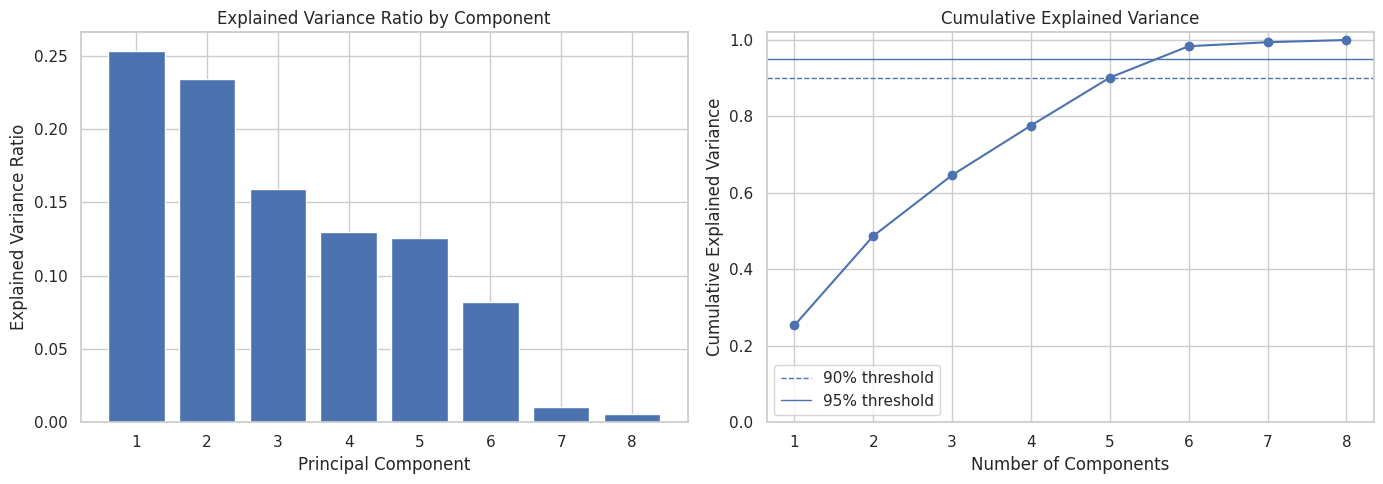

In [31]:
# Variance diagnostics from PCA fit on training data
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
components = np.arange(1, len(explained_var) + 1)

variance_df = pd.DataFrame(
    {
        "component": components,
        "explained_variance_ratio": explained_var,
        "cumulative_explained_variance": cum_explained_var,
    }
)

print("PCA variance diagnostics:")
print(variance_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: per-component explained variance
axes[0].bar(components, explained_var)
axes[0].set_title("Explained Variance Ratio by Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_xticks(components)

# Plot 2: cumulative explained variance
axes[1].plot(components, cum_explained_var, marker="o")
axes[1].axhline(0.90, linestyle="--", linewidth=1, label="90% threshold")
axes[1].axhline(0.95, linestyle="-", linewidth=1, label="95% threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_xticks(components)
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

The PCA variance profile is concentrated in the first few components:

- PC1 and PC2 together explain about **48.7%** of total variance.
- The first **5 components** explain about **90.2%** of variance (reaches the 90% threshold).
- The first **6 components** explain about **98.4%** of variance (well above 95%).
- Components 7 and 8 contribute very little (about **1.6%** combined), indicating diminishing returns.



I choose `k` using the cumulative explained-variance rule:

- **Primary rule (default):** smallest `k` with cumulative variance >= 90%.
- **Reference check:** smallest `k` with cumulative variance >= 95%.

Then I build reduced PCA feature matrices (`X_pca_train_k`, `X_pca_valid_k`) for downstream PCA-based modeling.

In [27]:
# Selection thresholds
PCA_TARGET_VAR_DEFAULT = 0.90
PCA_TARGET_VAR_REF = 0.95

# Smallest k that reaches each threshold
k_default = int(np.argmax(cum_explained_var >= PCA_TARGET_VAR_DEFAULT) + 1)
k_ref_95 = int(np.argmax(cum_explained_var >= PCA_TARGET_VAR_REF) + 1)

# Use 90% rule as the default modeling choice
k_pca = k_default

# Truncated PCA design matrices for model training/evaluation
X_pca_train_k = X_pca_train_full[:, :k_pca]
X_pca_valid_k = X_pca_valid_full[:, :k_pca]

print("PCA component selection summary:")
print(f"- k_default_90 (>= {PCA_TARGET_VAR_DEFAULT:.0%} variance): {k_default}")
print(f"- cumulative variance at k_default_90: {cum_explained_var[k_default - 1]:.6f}")
print(f"- k_ref_95 (>= {PCA_TARGET_VAR_REF:.0%} variance): {k_ref_95}")
print(f"- cumulative variance at k_ref_95: {cum_explained_var[k_ref_95 - 1]:.6f}")
print(f"- k_pca selected for modeling: {k_pca}")
print("\nTruncated PCA matrix shapes:")
print("- X_pca_train_k:", X_pca_train_k.shape)
print("- X_pca_valid_k:", X_pca_valid_k.shape)

PCA component selection summary:
- k_default_90 (>= 90% variance): 5
- cumulative variance at k_default_90: 0.901583
- k_ref_95 (>= 95% variance): 6
- cumulative variance at k_ref_95: 0.983748
- k_pca selected for modeling: 5

Truncated PCA matrix shapes:
- X_pca_train_k: (16512, 5)
- X_pca_valid_k: (4128, 5)


I now train regression models on the reduced PCA features (`k=5`) and evaluate them with `evaluate_model` so all metrics remain comparable across raw, engineered, and PCA tracks.

In [ ]:
# Train/evaluate PCA OLS and PCA RidgeCV

from sklearn.linear_model import LinearRegression, RidgeCV

# 1) OLS on PCA-reduced features
pca_ols = LinearRegression()
res_pca_ols = evaluate_model(
    pca_ols,
    X_pca_train_k,
    y_train,
    X_pca_valid_k,
    y_valid,
    model_name=f"PCA{int(k_pca)} OLS",
)
all_model_results.append(res_pca_ols)

# 2) RidgeCV on PCA-reduced features
pca_ridge = RidgeCV(alphas=ALPHA_GRID, cv=cv)
res_pca_ridge = evaluate_model(
    pca_ridge,
    X_pca_train_k,
    y_train,
    X_pca_valid_k,
    y_valid,
    model_name=f"PCA{int(k_pca)} RidgeCV",
)
all_model_results.append(res_pca_ridge)

pca_model_names = {f"PCA{int(k_pca)} OLS", f"PCA{int(k_pca)} RidgeCV"}
pca_results_df = pd.DataFrame([r for r in all_model_results if r["model"] in pca_model_names])

pca_results_df = pca_results_df[[
    "model",
    "train_rmse", "cv_rmse_mean", "cv_rmse_std", "val_rmse",
    "train_r2", "cv_r2_mean", "cv_r2_std", "val_r2",
]]

pca_results_df = pca_results_df.sort_values("val_rmse").reset_index(drop=True)
print(pca_results_df)

          model  train_rmse  cv_rmse_mean  cv_rmse_std  val_rmse  train_r2  \
0  PCA5 RidgeCV    0.852204      0.854769     0.019599  0.861888  0.456714   
1      PCA5 OLS    0.852193      0.854847     0.019854  0.862034  0.456729   

   cv_r2_mean  cv_r2_std    val_r2  
0    0.453231   0.017942  0.433115  
1    0.453128   0.018253  0.432923  


The two PCA-based models are almost identical in performance:

- `PCA5 OLS`: val RMSE = `0.862034`, val R2 = `0.432923`
- `PCA5 RidgeCV`: val RMSE = `0.861888`, val R2 = `0.433115`

Interpretation:

- PCA with `k=5` gives **stable** CV behavior (low fold-to-fold spread), but predictive performance is much weaker than the previous best engineered-feature models.
- This indicates a **higher-bias / information-loss** effect from dimensional compression: retaining 90% of feature variance does not guarantee retaining all target-relevant signal.
- Ridge adds little on top of PCA in this setting, likely because PCA already reduces strong collinearity, making OLS and Ridge behave similarly.

In [30]:
# Updated all-model comparison including PCA models

all_models_full_df = pd.DataFrame(all_model_results).copy()

# Keep latest entry per model if cells were rerun
all_models_full_df = all_models_full_df.drop_duplicates(subset=["model"], keep="last")

# Diagnostic gaps for bias/variance reading
all_models_full_df["train_val_rmse_gap"] = all_models_full_df["train_rmse"] - all_models_full_df["val_rmse"]
all_models_full_df["cv_val_rmse_gap"] = all_models_full_df["cv_rmse_mean"] - all_models_full_df["val_rmse"]

models_compare_full_cols = [
    "model",
    "train_rmse", "cv_rmse_mean", "cv_rmse_std", "val_rmse",
    "train_r2", "cv_r2_mean", "cv_r2_std", "val_r2",
    "train_val_rmse_gap", "cv_val_rmse_gap",
]

models_compare_full_df = all_models_full_df[models_compare_full_cols].sort_values(
    by=["val_rmse", "cv_rmse_mean"],
    ascending=[True, True],
).reset_index(drop=True)

print("Consolidated comparison (raw + engineered + PCA), ranked by val_rmse:")
print(models_compare_full_df)

pca_rows = models_compare_full_df[models_compare_full_df["model"].str.contains("PCA")].copy()
if not pca_rows.empty:
    pca_rows.insert(0, "rank", pca_rows.index + 1)
    print("\nPCA model ranks in consolidated table:")
    print(pca_rows[["rank", "model", "val_rmse", "val_r2", "cv_rmse_std"]])

best_model = models_compare_full_df.loc[0, "model"]
print(f"\nBest model after PCA inclusion: {best_model}")

Consolidated comparison (raw + engineered + PCA), ranked by val_rmse:
           model  train_rmse  cv_rmse_mean  cv_rmse_std  val_rmse  train_r2  \
0        Eng OLS    0.649956      0.651831     0.014450  0.665263  0.683985   
1    Eng RidgeCV    0.649956      0.654417     0.015930  0.665280  0.683985   
2    Eng LassoCV    0.658036      0.661235     0.014730  0.677501  0.676078   
3  Raw Poly2 OLS    0.648634      1.390345     1.379680  0.681397  0.685268   
4    Raw LassoCV    0.719693      0.722042     0.014599  0.744939  0.612532   
5    Raw RidgeCV    0.719677      0.720508     0.013898  0.745494  0.612550   
6        Raw OLS    0.719676      0.720510     0.013895  0.745581  0.612551   
7   PCA5 RidgeCV    0.852204      0.854769     0.019599  0.861888  0.456714   
8       PCA5 OLS    0.852193      0.854847     0.019854  0.862034  0.456729   

   cv_r2_mean  cv_r2_std    val_r2  train_val_rmse_gap  cv_val_rmse_gap  
0    0.682013   0.010786  0.662262           -0.015308        -0.

From the consolidated comparison, PCA models rank last (`8th` and `9th`) with substantially weaker validation performance than engineered-feature models:

- Best engineered model (`Eng OLS`): val RMSE `0.665263`, val R2 `0.662262`
- Best PCA model (`PCA5 RidgeCV`): val RMSE `0.861888`, val R2 `0.433115`

Key interpretation:

- PCA with `k=5` is reasonably stable (small CV spread), but it loses predictive signal relevant to `MedHouseVal`.
- This matches PCA theory: PCA is **unsupervised** and maximizes variance in `X`, not predictive relevance for `y`.
- Therefore, high explained variance (about 90%) does not guarantee strong supervised performance.
- In this case study, leakage-safe feature engineering preserves more target-relevant structure than PCA compression.



### Summary and conclusions

This study models `MedHouseVal` as a noisy function of income, housing composition, crowding, and geography, with omitted variables (schools, crime, amenities, policy) and sampling limits (California tracts, capped target).

Across models, leakage-safe engineered linear features produced the best balance of interpretability, validation accuracy, and stability (`Eng OLS` / `Eng RidgeCV`). Raw polynomial expansion captured extra signal but showed high variance instability across folds. PCA retained high variance in `X` but reduced supervised performance, highlighting the tradeoff between compression and target-relevant information.

# Final report 

House values are generated by income, housing composition, crowding, and location plus noise, omitted factors include schools, crime, and amenities. MedInc and engineered interaction/ratio/geo features improved linear model fit and interpretability. Raw polynomial terms increased variance instability, while engineered OLS/Ridge gave the best validation balance. PCA reduced interpretability and prediction quality versus engineered features despite high explained variance.
